In [1]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:

df = pd.read_csv('loan.csv')
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [4]:
df = df.drop('Loan_ID', axis=1)

In [5]:

X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

In [6]:
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban


In [7]:
y

0      Y
1      N
2      Y
3      Y
4      Y
      ..
609    Y
610    Y
611    Y
612    Y
613    N
Name: Loan_Status, Length: 614, dtype: object

In [8]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [9]:
# Feature type identification

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

categorical_features = X.select_dtypes(include=['object']).columns


In [10]:

numeric_features

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

In [11]:
categorical_features

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object')

In [12]:

# Preprocessing pipelines

numeric_transformer = Pipeline(steps=[
    
    ('imputer', SimpleImputer(strategy='median')),
    
    ('scaler', StandardScaler())])


In [13]:

numeric_transformer


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [14]:

categorical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])


In [15]:

categorical_transformer

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='missing', strategy='constant')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [16]:
# ColumnTransformer

preprocessor = ColumnTransformer(

    transformers=[
    
        ('num', numeric_transformer, numeric_features),
        
        ('cat', categorical_transformer, categorical_features)])


In [17]:

preprocessor 


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object'))])

In [18]:

from sklearn.ensemble import RandomForestClassifier

rf = Pipeline(steps=[('preprocessor', preprocessor),

                     ('classifier', RandomForestClassifier())])


In [19]:

rf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier())])

In [20]:

rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier())])

In [21]:

y_pred = rf.predict(X_test)

print(y_pred)

['Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'N' 'Y' 'Y' 'N' 'Y'
 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'N' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y'
 'Y' 'Y' 'N' 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y'
 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'N'
 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'N' 'Y' 'Y' 'N' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'N' 'N'
 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'N' 'N' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'N' 'Y'
 'Y' 'Y' 'Y' 'Y' 'N']


In [22]:

print(y_test)

350    Y
377    Y
163    Y
609    Y
132    Y
      ..
380    Y
446    Y
144    Y
290    Y
353    N
Name: Loan_Status, Length: 185, dtype: object


In [23]:

# Print accuracy & classification report

print("Initial Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Initial Accuracy: 0.772972972972973

Classification Report:
               precision    recall  f1-score   support

           N       0.81      0.46      0.59        65
           Y       0.76      0.94      0.84       120

    accuracy                           0.77       185
   macro avg       0.79      0.70      0.72       185
weighted avg       0.78      0.77      0.75       185




### Comparing classifiers

In [24]:
# List of classifiers and names

classifiers = [
    ('K-Nearest Neighbors', KNeighborsClassifier(3)),
    ('Support Vector Classifier', SVC()),
    ('Decision Tree', DecisionTreeClassifier()),
]


In [25]:
classifiers

[('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=3)),
 ('Support Vector Classifier', SVC()),
 ('Decision Tree', DecisionTreeClassifier())]

In [26]:
# Fit and evaluate each model

for name, model in classifiers:
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', model)])
    pipe.fit(X_train, y_train)
    score = pipe.score(X_test, y_test)
    print(f"{name} Accuracy: {score:.3f}")


K-Nearest Neighbors Accuracy: 0.778
Support Vector Classifier Accuracy: 0.784
Decision Tree Accuracy: 0.697


  File "C:\Users\nvgra\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\nvgra\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nvgra\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\nvgra\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


In [28]:

import seaborn as sns
import matplotlib.pyplot as plt

model_scores = []

for name, model in classifiers:
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', model)])
    pipe.fit(X_train, y_train)
    score = pipe.score(X_test, y_test)
    model_scores.append((name, score))


In [29]:
model_scores

[('K-Nearest Neighbors', 0.7783783783783784),
 ('Support Vector Classifier', 0.7837837837837838),
 ('Decision Tree', 0.6972972972972973)]

In [30]:
names = [x[0] for x in model_scores]
scores = [x[1] for x in model_scores]

In [31]:
names

['K-Nearest Neighbors', 'Support Vector Classifier', 'Decision Tree']

In [32]:
scores

[0.7783783783783784, 0.7837837837837838, 0.6972972972972973]

('Random Forest', 0.82),
  ('K-Nearest Neighbors', 0.75),
  ('Support Vector Classifier', 0.79),
  ('Decision Tree', 0.73)

### horizontal lollipop chart

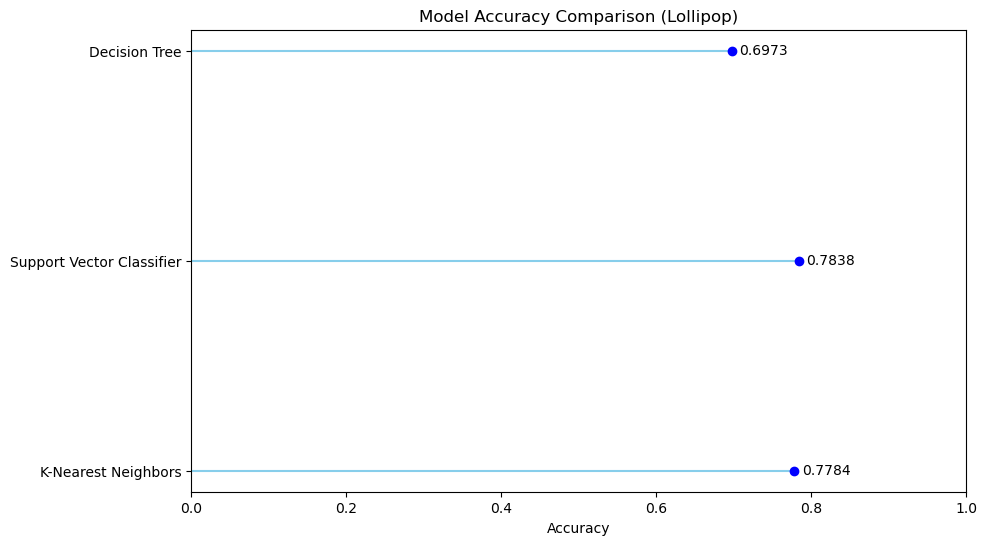

In [34]:
plt.figure(figsize=(10, 6))
plt.hlines(y=names, xmin=0, xmax=scores, color='skyblue')
plt.plot(scores, names, "o", color='blue')

for i, v in enumerate(scores):
    plt.text(v + 0.01, names[i], f"{v:.4f}", va='center')

plt.xlabel("Accuracy")
plt.title("Model Accuracy Comparison (Lollipop)")
plt.xlim(0, 1)
plt.show()


hlines(...) → draws a horizontal line from 0 → model’s accuracy score.

plot(scores, names, "o", ...) → puts a dot at the end of each line.

text(...) → writes the exact accuracy value next to each dot.

xlim(0,1) → keeps scale fixed since accuracy is bounded.

In [35]:
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

y_pred = pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm

array([[32, 33],
       [23, 97]], dtype=int64)